In [1]:
# 🧪 ControllerProvider Log Expansion — FSMOutput + Output Detail Fields

import os, sys, json
import pandas as pd
from pathlib import Path

# 📁 Set up paths
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

LOG_PATH = Path("tests/backup/provider_logs.csv")
assert LOG_PATH.exists(), "❌ provider_logs.csv not found"

# 📥 Load log data
df = pd.read_csv(LOG_PATH)

# 🔍 Filter only CONTROLLER provider logs
df_controller = df[df["provider_type"] == "PROVIDER_TYPE.CONTROLLER"].copy()

# 🧼 Safe JSON parse
def safe_json_parse(val):
    try:
        return json.loads(val) if isinstance(val, str) else {}
    except Exception:
        return {}

df_controller["output_parsed"] = df_controller["output"].apply(safe_json_parse)

# 🧩 Extract FSMOutputSchema fields
df_controller["state"] = df_controller["output_parsed"].apply(lambda x: x.get("state"))
df_controller["previous_state"] = df_controller["output_parsed"].apply(lambda x: x.get("previous_state"))
df_controller["state_type"] = df_controller["output_parsed"].apply(lambda x: x.get("state_type"))
df_controller["decision"] = df_controller["output_parsed"].apply(lambda x: x.get("decision"))
df_controller["steps"] = df_controller["output_parsed"].apply(lambda x: x.get("steps"))
df_controller["max_steps"] = df_controller["output_parsed"].apply(lambda x: x.get("max_steps"))
df_controller["summary"] = df_controller["output_parsed"].apply(lambda x: x.get("summary"))
df_controller["fsm_output"] = df_controller["output_parsed"].apply(lambda x: x.get("output"))
df_controller["provider_name"] = df_controller["output_parsed"].apply(lambda x: x.get("provider_name"))

# 🧬 Expand fsm_output structure
df_controller["fsm_file_path"] = df_controller["fsm_output"].apply(lambda x: x.get("file_path") if isinstance(x, dict) else None)
df_controller["fsm_reason"] = df_controller["fsm_output"].apply(lambda x: x.get("reason") if isinstance(x, dict) else None)
df_controller["fsm_retry_count"] = df_controller["fsm_output"].apply(lambda x: x.get("retry_count") if isinstance(x, dict) else None)
df_controller["fsm_last_state"] = df_controller["fsm_output"].apply(lambda x: x.get("_last_state") if isinstance(x, dict) else None)
df_controller["fsm_output_steps"] = df_controller["fsm_output"].apply(lambda x: x.get("steps") if isinstance(x, dict) else None)

# 📐 Select final columns
feature_cols = [
    "timestamp", "provider_id", "file_log_id", "run_id",
    "state", "previous_state", "state_type", "decision", "steps", "max_steps",
    "latency_ms", "provider_name", "summary",
    "fsm_file_path", "fsm_reason", "fsm_retry_count", "fsm_last_state", "fsm_output_steps"
]

df_controller_view = df_controller[feature_cols].sort_values("timestamp")

pd.set_option("display.max_colwidth", 200)
df_controller_view.head(20)


,timestamp,provider_id,file_log_id,run_id,state,previous_state,state_type,decision,steps,max_steps,latency_ms,provider_name,summary,fsm_file_path,fsm_reason,fsm_retry_count,fsm_last_state,fsm_output_steps
63,2025-06-16 04:00:05.375860+00:00,1,1,b77d20df-9a26-4246-a1f5-03b4584d9256,end,linting,end,accepted,3,10,9876,preprocessing_controller,Completed,working_files\temp_ctrl_2300152493.py,completed successfully,0,linting,3
136,2025-06-16 04:00:16.771991+00:00,1,2,456ae196-33e5-4bbc-891f-8d6a03eecdc2,end,linting,end,accepted,3,10,11133,preprocessing_controller,Completed,working_files\temp_ctrl_2300279008.py,completed successfully,0,linting,3
209,2025-06-16 04:00:29.683338+00:00,1,3,d869c4ad-06be-4fe5-bcf4-360490c41301,end,linting,end,accepted,3,10,11330,preprocessing_controller,Completed,working_files\temp_ctrl_2300410124.py,completed successfully,0,linting,3
282,2025-06-16 04:00:42.717933+00:00,1,4,8351b18f-d5eb-4f4d-bf92-fe07f4a54965,end,linting,end,accepted,3,10,11233,preprocessing_controller,Completed,working_files\temp_ctrl_2300539490.py,completed successfully,0,linting,3
355,2025-06-16 04:00:55.677708+00:00,1,5,e986f070-b2c5-49f2-bac4-29c34af4905e,end,linting,end,accepted,3,10,11053,preprocessing_controller,Completed,working_files\temp_ctrl_2301067285.py,completed successfully,0,linting,3
428,2025-06-16 04:01:08.423365+00:00,1,6,65abf1d6-104f-44cb-a747-c92139717110,end,linting,end,accepted,3,10,11240,preprocessing_controller,Completed,working_files\temp_ctrl_2301196608.py,completed successfully,0,linting,3
501,2025-06-16 04:01:21.468318+00:00,1,7,64d9180a-0d38-47c6-adf7-91facc8c2f2e,end,linting,end,accepted,3,10,11066,preprocessing_controller,Completed,working_files\temp_ctrl_2301325320.py,completed successfully,0,linting,3
574,2025-06-16 04:01:34.200423+00:00,1,8,41a05e1f-835b-48ac-803e-8c0536281b6d,end,linting,end,accepted,3,10,11008,preprocessing_controller,Completed,working_files\temp_ctrl_2301452060.py,completed successfully,0,linting,3
647,2025-06-16 04:01:46.973934+00:00,1,9,0a19a05d-dda1-4b7e-9f1d-b1593d6df2f2,end,linting,end,accepted,3,10,10820,preprocessing_controller,Completed,working_files\temp_ctrl_2301577914.py,completed successfully,0,linting,3
720,2025-06-16 04:01:59.726956+00:00,1,10,c3f36b7e-5a77-4c98-89cc-9c3059763927,end,linting,end,accepted,3,10,11668,preprocessing_controller,Completed,working_files\temp_ctrl_2302113929.py,completed successfully,0,linting,3


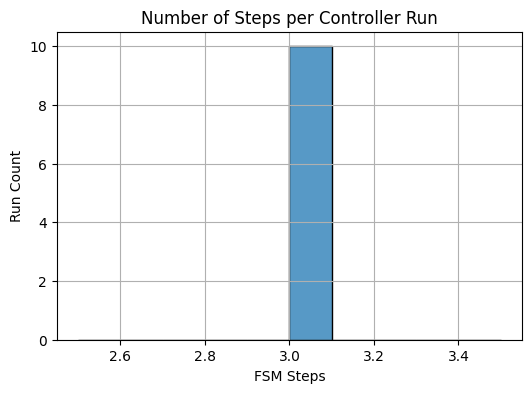

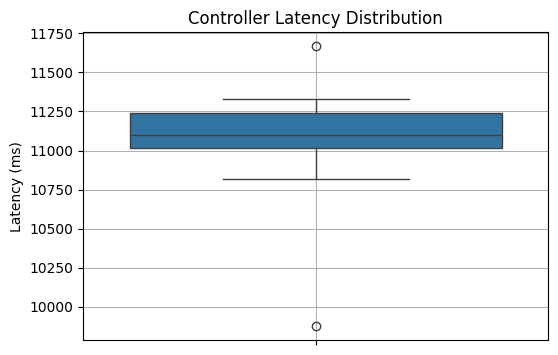

In [2]:
# 📈 Distribution of Steps and Latency for Controller Runs

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of FSM steps
plt.figure(figsize=(6, 4))
sns.histplot(df_controller_view["steps"], bins=10, kde=False)
plt.title("Number of Steps per Controller Run")
plt.xlabel("FSM Steps")
plt.ylabel("Run Count")
plt.grid(True)
plt.show()

# Latency distribution
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_controller_view, y="latency_ms")
plt.title("Controller Latency Distribution")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.show()


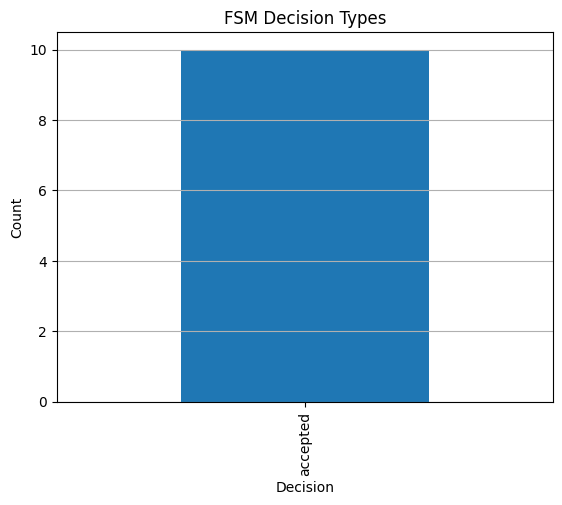

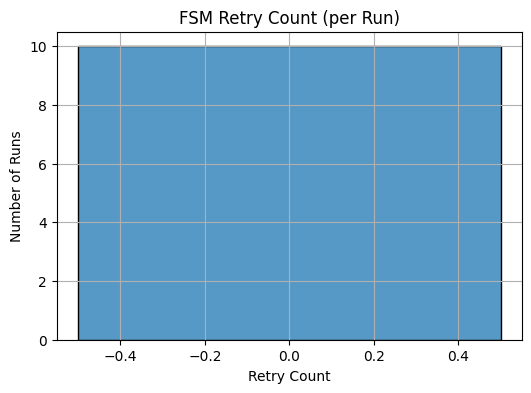

In [3]:
# 📊 Decision Type Breakdown and Retry Count Analysis

# Decision counts
decision_counts = df_controller_view["decision"].value_counts().sort_index()
decision_counts.plot(kind="bar", title="FSM Decision Types", ylabel="Count", xlabel="Decision")
plt.grid(axis='y')
plt.show()

# Retry count (even though all are 0, this sets up future insight)
plt.figure(figsize=(6, 4))
sns.histplot(df_controller_view["fsm_retry_count"], bins=5, discrete=True)
plt.title("FSM Retry Count (per Run)")
plt.xlabel("Retry Count")
plt.ylabel("Number of Runs")
plt.grid(True)
plt.show()
